# Futures/Spot HBT Step-by-Step Runner

The notebook is intentionally thin. Configuration, pipeline stages, report tables, and plotting live in separate Python scripts in this folder. Both this notebook and `run_full_backtest.py` save CSV reports and PNG figures.

In [2]:
from pathlib import Path
import sys

CURRENT_DIR = Path.cwd().resolve()
TEST_ROOT = CURRENT_DIR if (CURRENT_DIR / 'backtest_config.py').exists() else CURRENT_DIR / 'future_spot' / 'test'
if not TEST_ROOT.exists():
    raise FileNotFoundError('Open this notebook from future_spot/test or the repository root')
PROJECT_ROOT = TEST_ROOT.parent
WORKSPACE_ROOT = PROJECT_ROOT.parent
for path in (TEST_ROOT, PROJECT_ROOT, WORKSPACE_ROOT, PROJECT_ROOT / 'scripts'):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

from IPython.display import Image, display
from backtest_config import default_notebook_args
from backtest_pipeline import run_backtest_pipeline
from report_tables import build_report_tables
from report_plots import save_report_plots

## 1. Parameters

In [3]:
args = default_notebook_args(
    start_date='2026-05-21',
    end_date='2026-05-26',
    order_latency_ms=10.0,
    response_latency_ms=10.0,
    feed_latency_offset_ms=10.0,
    post_first_feed_wait='spot',
    post_first_feed_timeout_ms=5000.0,
    rebuild_hbt_results=True,
)
args.output_dir

PosixPath('/home/zoufuc/hftbacktest/future_spot/output/hbt_daily_full_market_20260521_20260526_latency_10ms')

## 2. Full Backtest and Core CSV Outputs

In [4]:
artifacts = run_backtest_pipeline(args)
display(artifacts.frame('summary').head(20))
display(artifacts.frame('entry_exit_index').head(20))

,trade_date,run_key,pair_name,spot_symbol,future_symbol,rows,filled_pairs,second_leg_failures,flatten_count,realized_pnl,...,spot_tick_size,future_tick_size,first_leg,step_ns,second_leg_delay_ns,post_first_feed_wait,post_first_feed_timeout_ns,post_first_feed_poll_ns,spot_order_latency_ns,future_order_latency_ns
0,2026-05-21,2026-05-21::1303_CAFE6,1303_CAFE6,1303,CAFE6,0,0,0,0,0.0,...,0.10,1.00,future,1000000000,0,spot,5000000000,1000000,10000000,10000000
1,2026-05-21,2026-05-21::2324_CGFE6,2324_CGFE6,2324,CGFE6,0,0,0,0,0.0,...,0.05,1.00,future,1000000000,0,spot,5000000000,1000000,10000000,10000000
2,2026-05-21,2026-05-21::2409_CHFE6,2409_CHFE6,2409,CHFE6,0,0,0,0,0.0,...,0.05,1.00,future,1000000000,0,spot,5000000000,1000000,10000000,10000000
3,2026-05-21,2026-05-21::1605_CSFF6,1605_CSFF6,1605,CSFF6,0,0,0,0,0.0,...,0.05,0.05,future,1000000000,0,spot,5000000000,1000000,10000000,10000000
4,2026-05-21,2026-05-21::2408_CYFE6,2408_CYFE6,2408,CYFE6,0,0,0,0,0.0,...,0.50,1.00,future,1000000000,0,spot,5000000000,1000000,10000000,10000000
5,2026-05-21,2026-05-21::2603_CZFE6,2603_CZFE6,2603,CZFE6,0,0,0,0,0.0,...,0.50,1.00,future,1000000000,0,spot,5000000000,1000000,10000000,10000000
6,2026-05-21,2026-05-21::2609_DAFF6,2609_DAFF6,2609,DAFF6,0,0,0,0,0.0,...,0.05,0.05,future,1000000000,0,spot,5000000000,1000000,10000000,10000000
7,2026-05-21,2026-05-21::2317_DHFE6,2317_DHFE6,2317,DHFE6,0,0,0,0,0.0,...,0.50,1.00,future,1000000000,0,spot,5000000000,1000000,10000000,10000000
8,2026-05-21,2026-05-21::2337_DIFE6,2337_DIFE6,2337,DIFE6,0,0,0,0,0.0,...,0.50,1.00,future,1000000000,0,spot,5000000000,1000000,10000000,10000000
9,2026-05-21,2026-05-21::3481_DQFE6,3481_DQFE6,3481,DQFE6,0,0,0,0,0.0,...,0.05,1.00,future,1000000000,0,spot,5000000000,1000000,10000000,10000000


,trade_date,run_key,pair_name,rows,entry_signal_rows,entry_execution_rows,exit_execution_rows
0,2026-05-21,2026-05-21::1303_CAFE6,1303_CAFE6,0,0,0,0
1,2026-05-21,2026-05-21::2324_CGFE6,2324_CGFE6,0,0,0,0
2,2026-05-21,2026-05-21::2409_CHFE6,2409_CHFE6,0,0,0,0
3,2026-05-21,2026-05-21::1605_CSFF6,1605_CSFF6,0,0,0,0
4,2026-05-21,2026-05-21::2408_CYFE6,2408_CYFE6,0,0,0,0
5,2026-05-21,2026-05-21::2603_CZFE6,2603_CZFE6,0,0,0,0
6,2026-05-21,2026-05-21::2609_DAFF6,2609_DAFF6,0,0,0,0
7,2026-05-21,2026-05-21::2317_DHFE6,2317_DHFE6,0,0,0,0
8,2026-05-21,2026-05-21::2337_DIFE6,2337_DIFE6,0,0,0,0
9,2026-05-21,2026-05-21::3481_DQFE6,3481_DQFE6,0,0,0,0


## 3. Analysis CSV Outputs

In [5]:
reports = build_report_tables(artifacts)
display(reports.frame('symbol_profit').head(30))
display(reports.frame('failure_overview'))
display(reports.frame('roi_summary_including_open'))
print(f'Report CSV directory: {reports.output_dir}')

,spot_symbol,trade_days,pair_names,estimated_profit,avg_daily_profit,filled_pairs,second_leg_failures,flatten_count,final_quantity_abs
0,3037,4,2,105759.64800,26439.912000,30,0,0,10.0
1,2455,3,2,43553.90800,14517.969333,30,0,0,10.0
2,8046,1,1,31742.02200,31742.022000,18,1,0,10.0
3,2408,4,2,29298.56600,7324.641500,56,0,0,20.0
4,4958,4,2,19664.44200,4916.110500,30,0,0,10.0
5,2481,4,2,19016.43800,4754.109500,52,0,0,10.0
6,2344,4,2,18306.00200,4576.500500,32,0,0,0.0
7,6271,2,1,17838.05500,8919.027500,20,1,0,0.0
8,3481,4,2,17738.27970,4434.569925,62,0,0,20.0
9,2367,3,1,17576.27880,5858.759600,50,0,0,10.0


,pairs_with_summary_failures,failure_trade_rows,market_window_rows,trade_dates,pair_names,flatten_count
0,5,5,105,3,5,1.0


,entry_cash_out,net_stock_cash_stuck,realized_pnl,open_locked_pnl,total_pnl_including_open,total_roi_on_entry_cash_pct,open_roi_on_stuck_cash_pct,open_pairs
0,3.505075e+08,2.378158e+08,427050.00678,2.384102e+06,2.811152e+06,0.00802,0.010025,558.0


Report CSV directory: /home/zoufuc/hftbacktest/future_spot/output/hbt_daily_full_market_20260521_20260526_latency_10ms/reports


## 4. Saved PNG Outputs

performance_overview: /home/zoufuc/hftbacktest/future_spot/output/hbt_daily_full_market_20260521_20260526_latency_10ms/figures/performance_overview.png


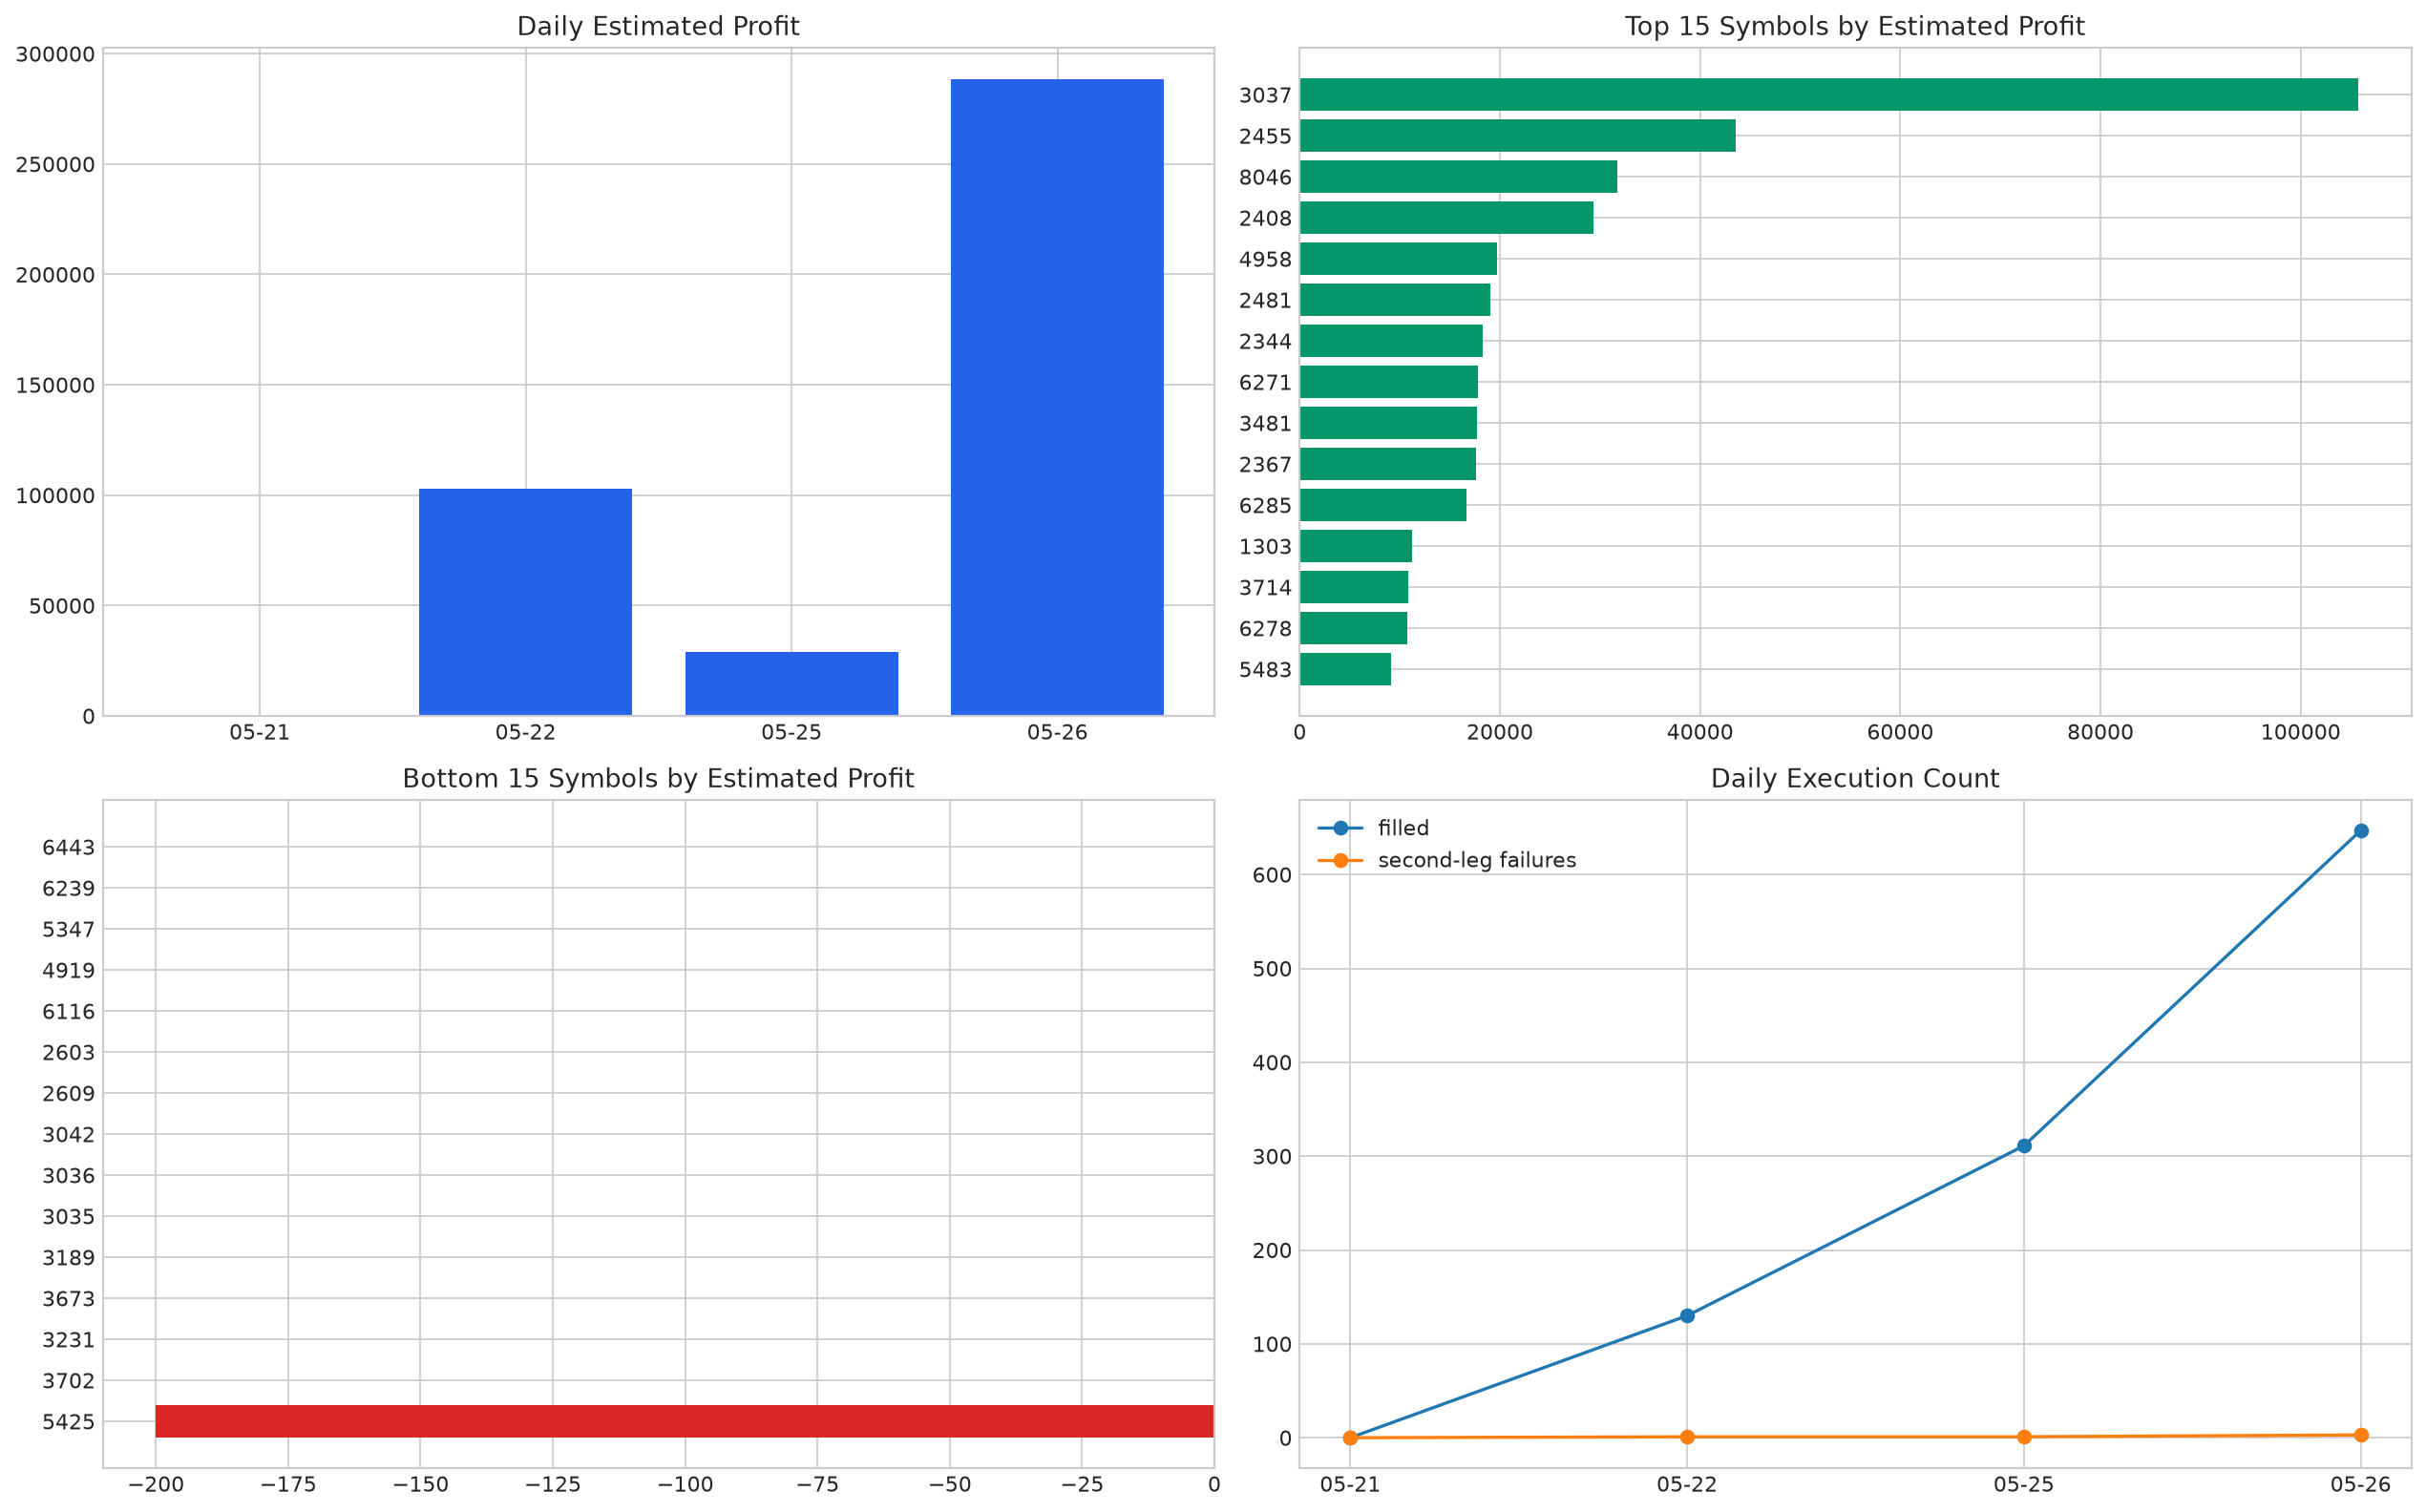

pair_profit_scatter: /home/zoufuc/hftbacktest/future_spot/output/hbt_daily_full_market_20260521_20260526_latency_10ms/figures/pair_profit_scatter.png


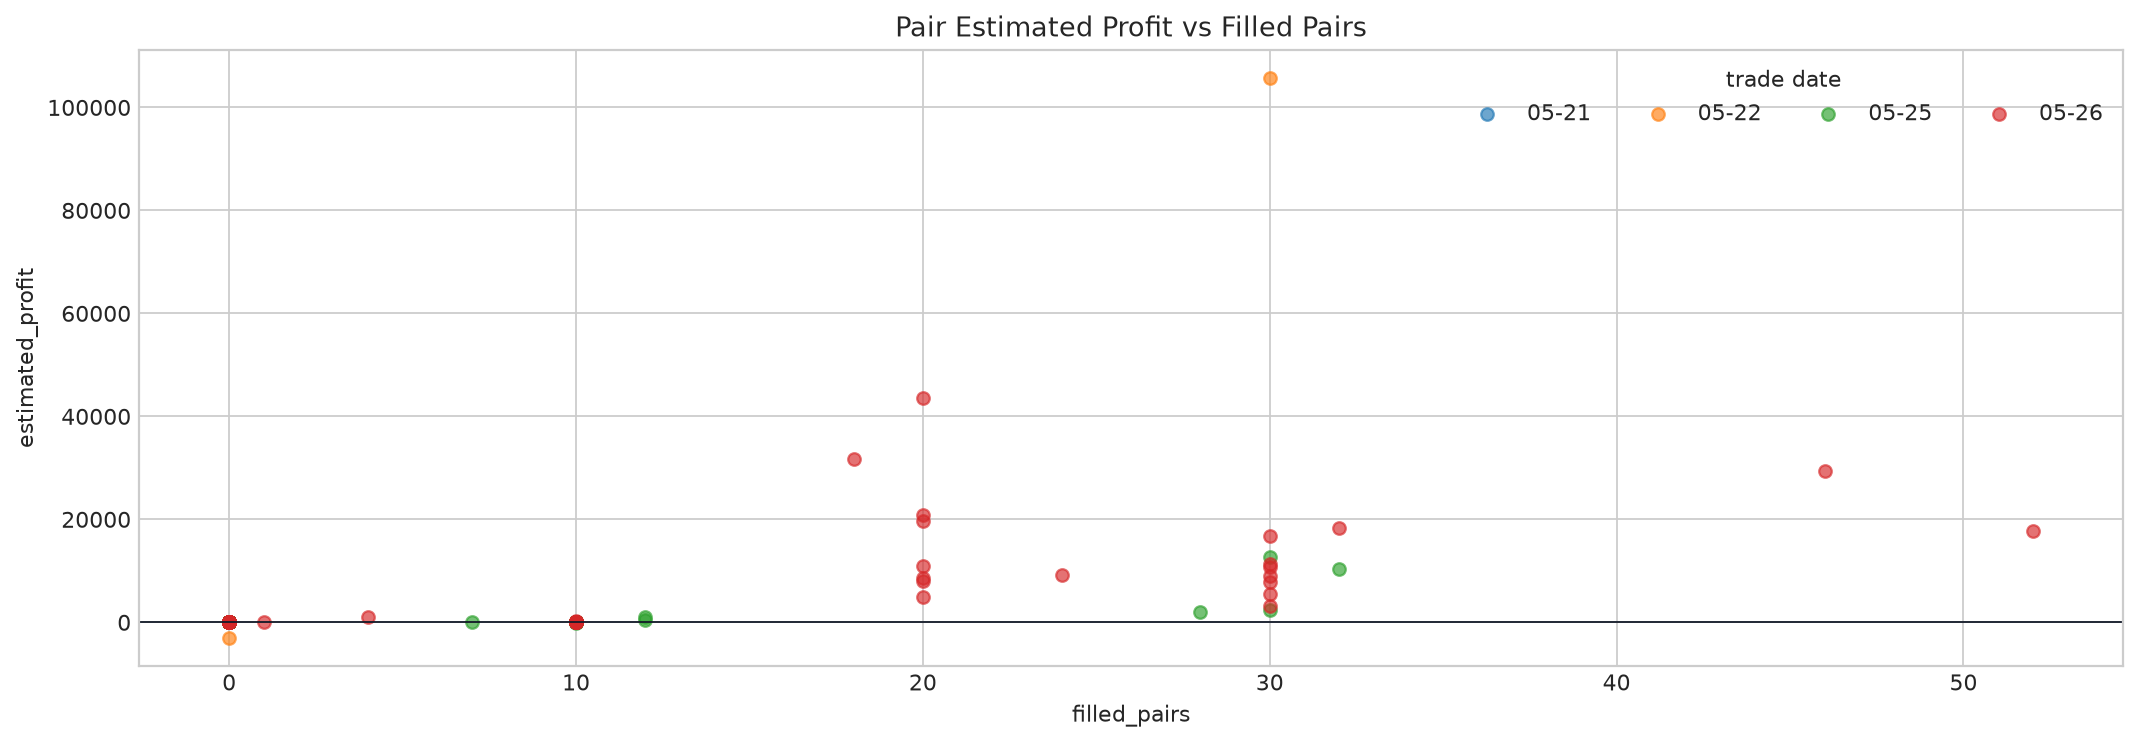

stuck_cash: /home/zoufuc/hftbacktest/future_spot/output/hbt_daily_full_market_20260521_20260526_latency_10ms/figures/stuck_cash.png


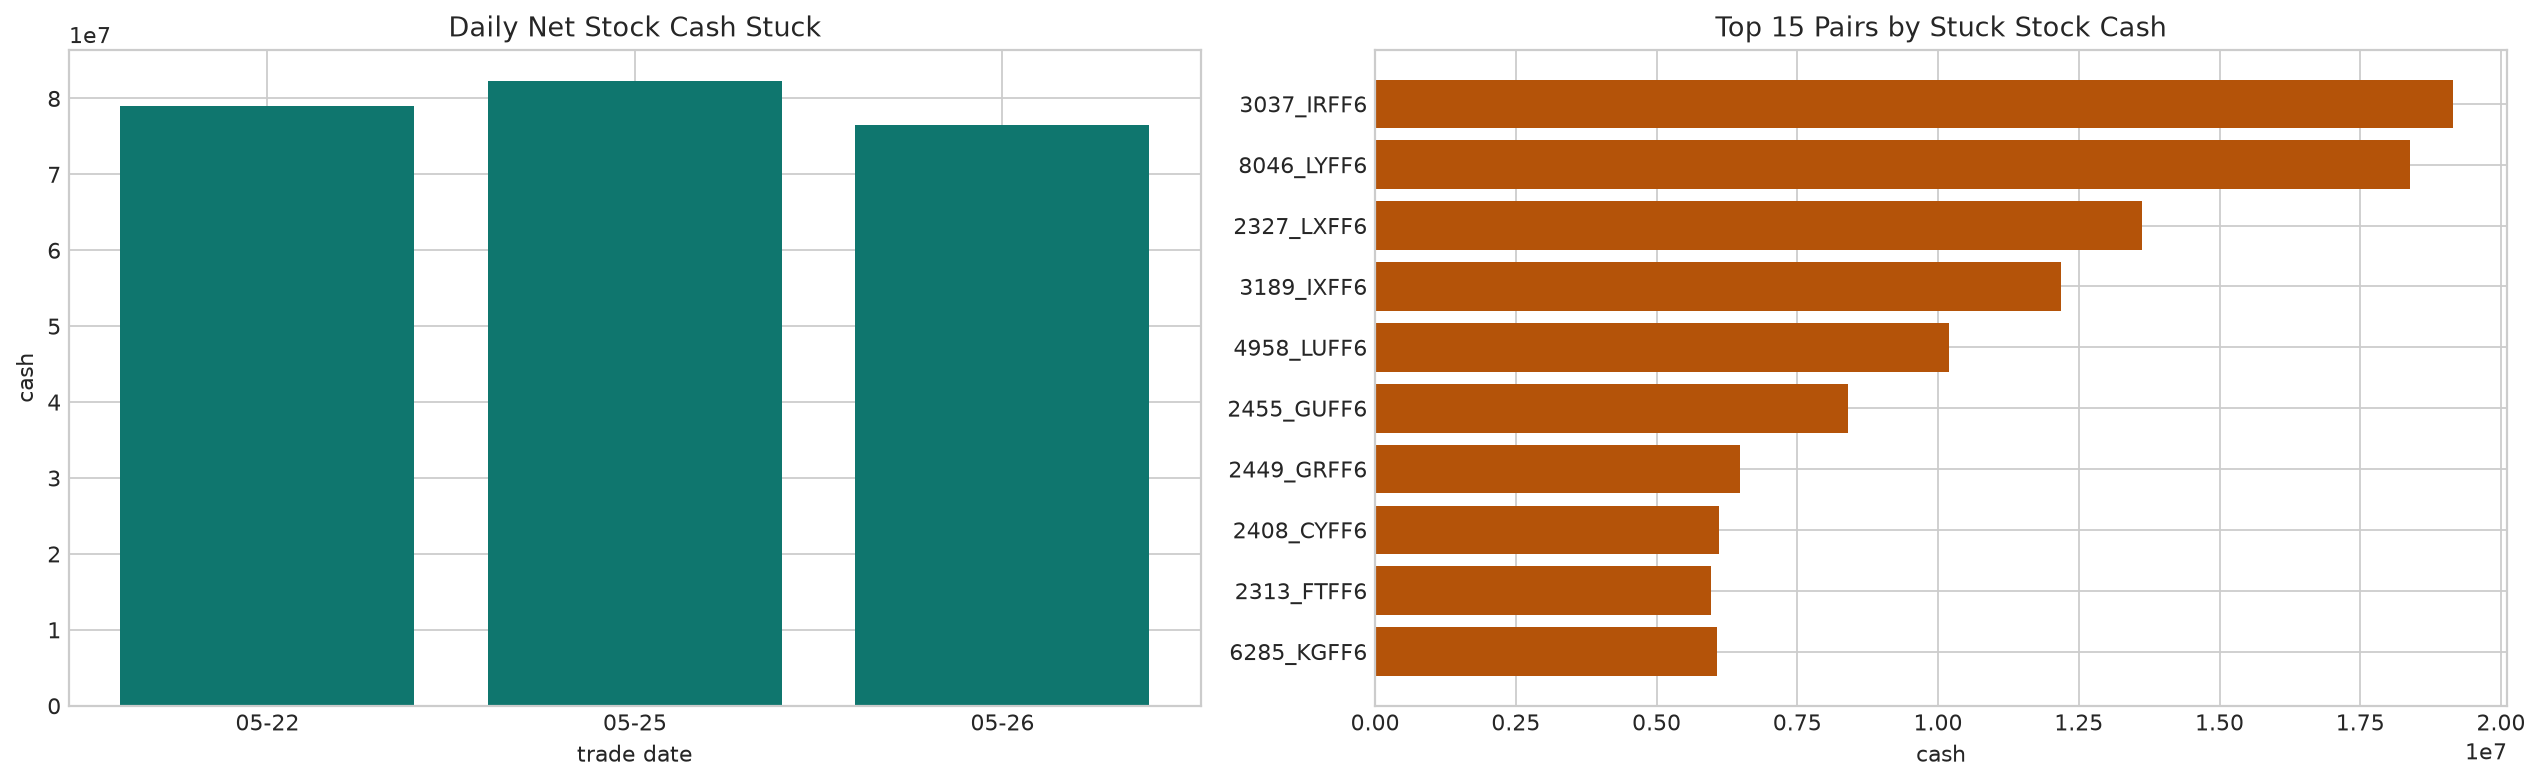

roi_including_open: /home/zoufuc/hftbacktest/future_spot/output/hbt_daily_full_market_20260521_20260526_latency_10ms/figures/roi_including_open.png


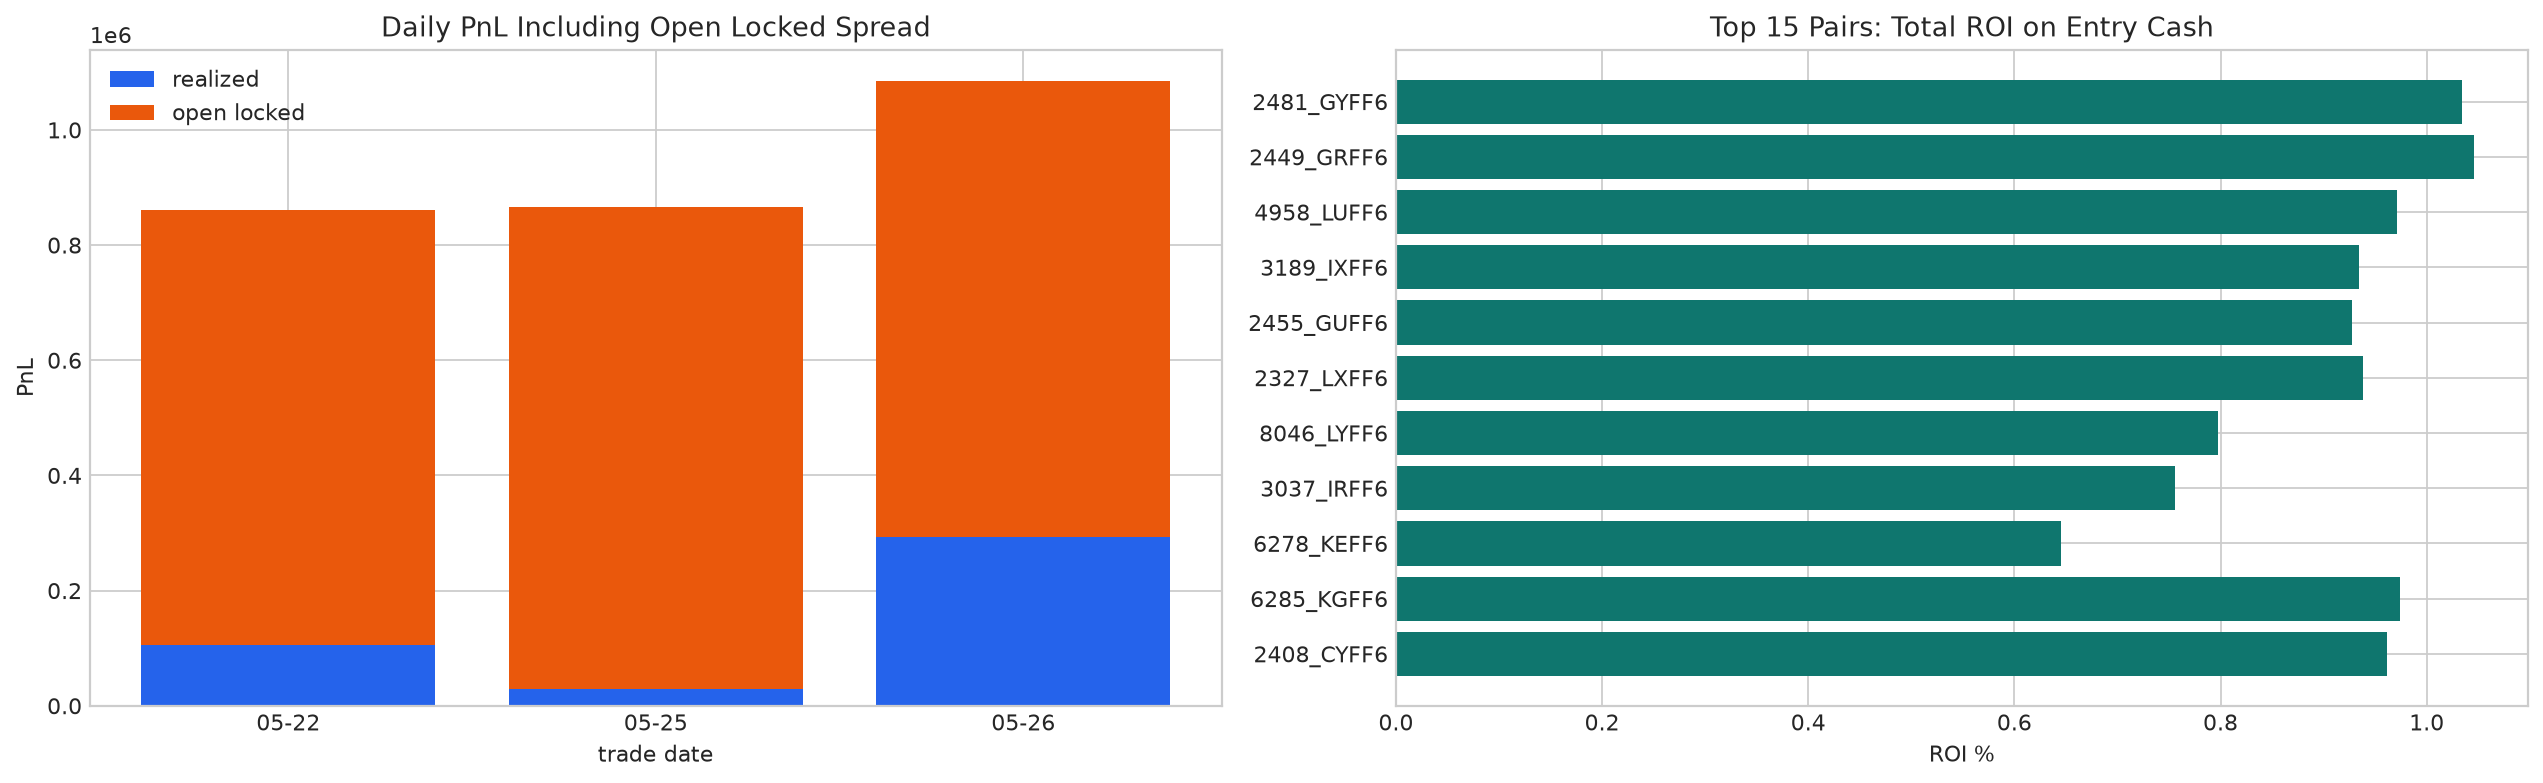

latency_timelines: /home/zoufuc/hftbacktest/future_spot/output/hbt_daily_full_market_20260521_20260526_latency_10ms/figures/latency_timelines.png


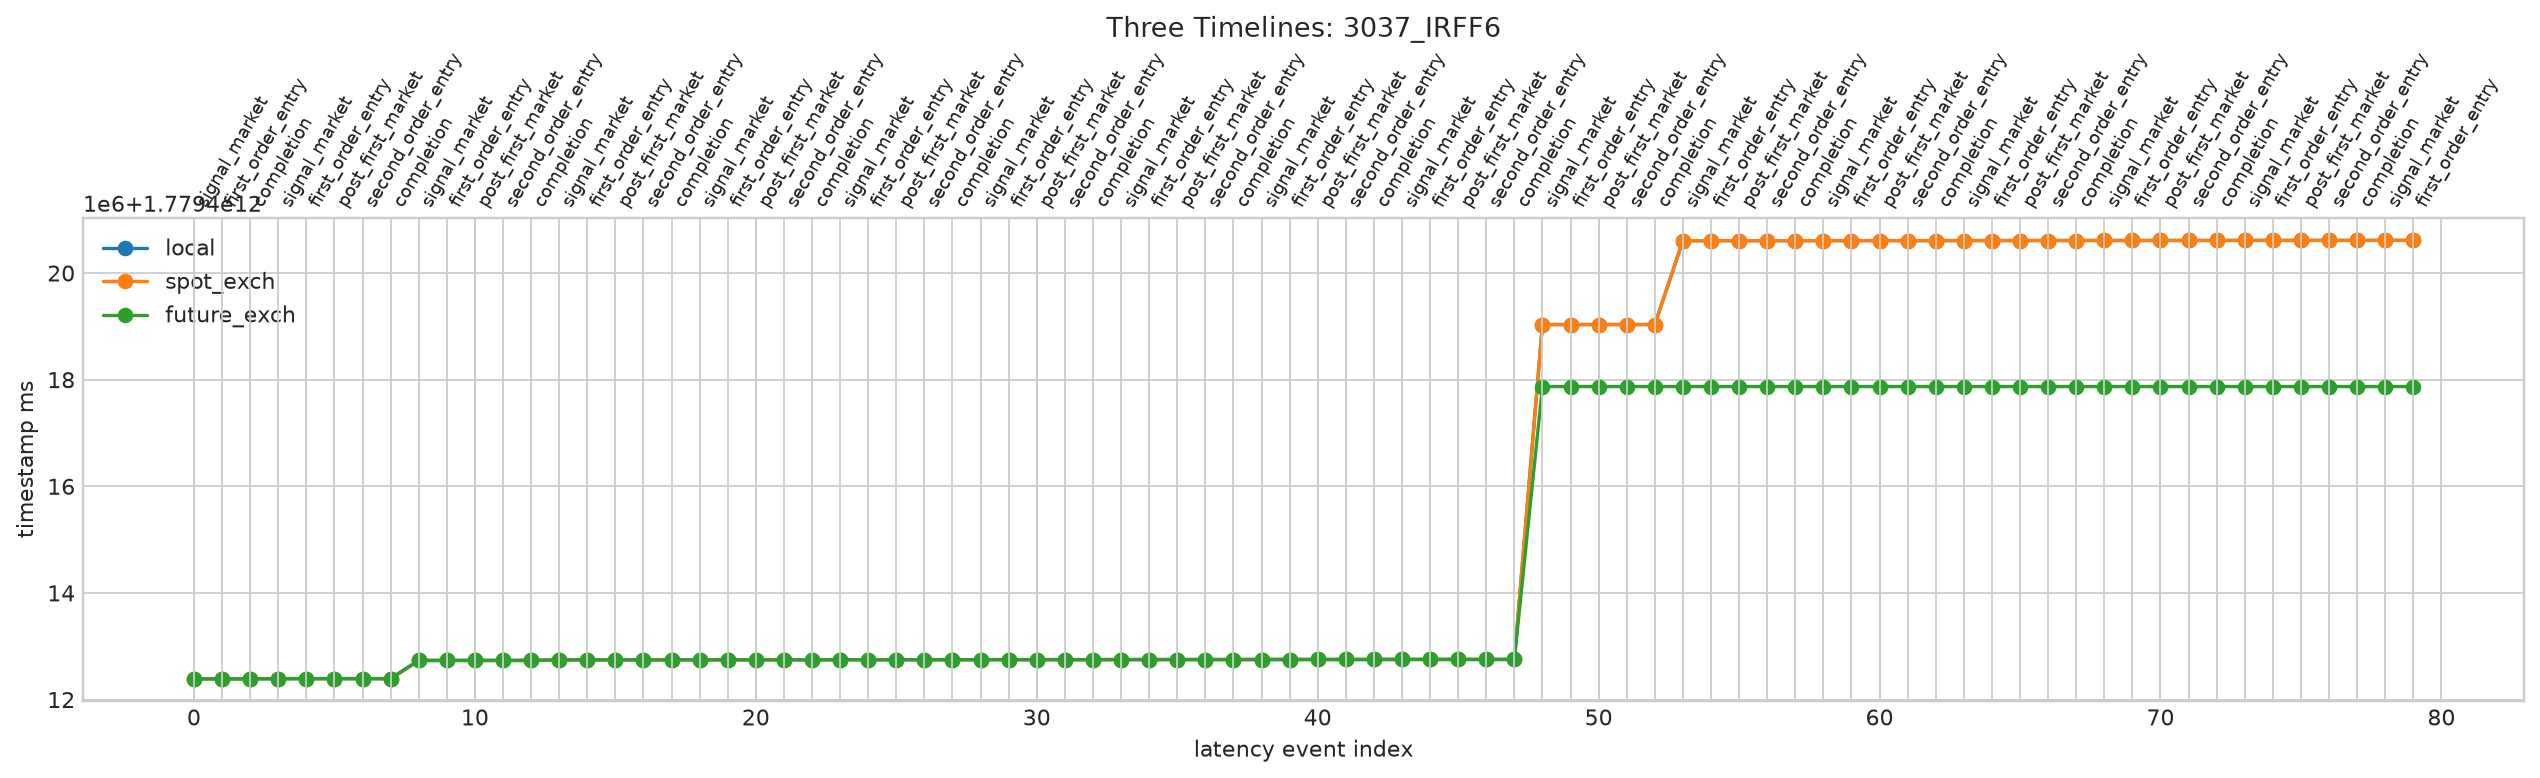

In [6]:
figure_paths = save_report_plots(artifacts, reports)
for name, path in figure_paths.items():
    print(f'{name}: {path}')
    display(Image(filename=str(path)))

## 5. Optional Drill-down

In [7]:
selected_pair = reports.selected_pair
entry_exit = artifacts.frame('entry_exit_all')
latency = artifacts.frame('latency')
if selected_pair is None:
    print('No pair is available for drill-down.')
else:
    if 'pair_name' in entry_exit.columns:
        display(entry_exit.loc[entry_exit['pair_name'].eq(selected_pair)].head(100))
    if 'pair_name' in latency.columns:
        display(latency.loc[latency['pair_name'].eq(selected_pair)].head(120))

,trade_date,run_key,time,pair_name,spot_symbol,future_symbol,entry_signal,spot_bid,spot_ask,spot_ask_size,...,first_side,first_requested_price,first_exec_price,first_exec_qty,second_leg,second_side,second_requested_price,second_exec_price,second_exec_qty,first_to_second_exch_ms
742,2026-05-22,2026-05-22::3037_IRFF6,2026-05-22 09:13:09.102000+08:00,3037_IRFF6,3037,IRFF6,ENTER_LONG_SPOT_SHORT_FUTURE,967.0,968.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
743,2026-05-22,2026-05-22::3037_IRFF6,2026-05-22 09:13:09.142000+08:00,3037_IRFF6,3037,IRFF6,ENTER_LONG_SPOT_SHORT_FUTURE,967.0,968.0,NaN,...,sell,981.0,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN
744,2026-05-22,2026-05-22::3037_IRFF6,2026-05-22 09:13:13.142000+08:00,3037_IRFF6,3037,IRFF6,ENTER_LONG_SPOT_SHORT_FUTURE,968.0,969.0,13.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
745,2026-05-22,2026-05-22::3037_IRFF6,2026-05-22 09:13:13.207000+08:00,3037_IRFF6,3037,IRFF6,ENTER_LONG_SPOT_SHORT_FUTURE,968.0,969.0,NaN,...,sell,982.0,982.0,1.0,stock,buy,971.0,969.0,2.0,44.999936
746,2026-05-22,2026-05-22::3037_IRFF6,2026-05-22 09:18:24.207000+08:00,3037_IRFF6,3037,IRFF6,ENTER_LONG_SPOT_SHORT_FUTURE,958.0,959.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
837,2026-05-22,2026-05-22::3037_IRFF6,2026-05-22 11:04:28.127000+08:00,3037_IRFF6,3037,IRFF6,ENTER_LONG_SPOT_SHORT_FUTURE,968.0,969.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
838,2026-05-22,2026-05-22::3037_IRFF6,2026-05-22 11:04:29.127000+08:00,3037_IRFF6,3037,IRFF6,ENTER_LONG_SPOT_SHORT_FUTURE,968.0,969.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
839,2026-05-22,2026-05-22::3037_IRFF6,2026-05-22 11:04:29.127000+08:00,3037_IRFF6,3037,IRFF6,ENTER_LONG_SPOT_SHORT_FUTURE,968.0,969.0,27.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
840,2026-05-22,2026-05-22::3037_IRFF6,2026-05-22 11:04:30.127000+08:00,3037_IRFF6,3037,IRFF6,ENTER_LONG_SPOT_SHORT_FUTURE,968.0,969.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,trade_date,run_key,timestamp,step,pair_name,spot_symbol,future_symbol,signal,status,failure_reason,...,spot_feed_latency_ns,future_exch_ts,future_feed_local_ts,future_feed_latency_ns,order_req_local_ts,order_exch_ts,order_resp_local_ts,order_entry_latency_ns,order_response_latency_ns,time
165,2026-05-22,2026-05-22::3037_IRFF6,1779412389102000000,789,3037_IRFF6,3037,IRFF6,ENTER_LONG_SPOT_SHORT_FUTURE,SIGNAL,None,...,10000000,1779412389071000000,1779412389081000000,10000000,NaN,NaN,NaN,NaN,NaN,2026-05-22 09:13:09.102000+08:00
166,2026-05-22,2026-05-22::3037_IRFF6,1779412389142000000,789,3037_IRFF6,3037,IRFF6,ENTER_LONG_SPOT_SHORT_FUTURE,FIRST_ORDER_RESPONSE,None,...,10000000,1779412389129000000,1779412389139000000,10000000,1.779412e+18,1.779412e+18,1.779412e+18,10000000.0,10000000.0,2026-05-22 09:13:09.102000+08:00
167,2026-05-22,2026-05-22::3037_IRFF6,1779412389142000000,789,3037_IRFF6,3037,IRFF6,ENTER_LONG_SPOT_SHORT_FUTURE,FIRST_LEG_UNFILLED,None,...,10000000,1779412389129000000,1779412389139000000,10000000,NaN,NaN,NaN,NaN,NaN,2026-05-22 09:13:09.142000+08:00
168,2026-05-22,2026-05-22::3037_IRFF6,1779412393142000000,793,3037_IRFF6,3037,IRFF6,ENTER_LONG_SPOT_SHORT_FUTURE,SIGNAL,None,...,10000000,1779412393069000000,1779412393079000000,10000000,NaN,NaN,NaN,NaN,NaN,2026-05-22 09:13:13.142000+08:00
169,2026-05-22,2026-05-22::3037_IRFF6,1779412393162000000,793,3037_IRFF6,3037,IRFF6,ENTER_LONG_SPOT_SHORT_FUTURE,FIRST_ORDER_RESPONSE,None,...,10000000,1779412393069000000,1779412393079000000,10000000,1.779412e+18,1.779412e+18,1.779412e+18,10000000.0,10000000.0,2026-05-22 09:13:13.142000+08:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
280,2026-05-22,2026-05-22::3037_IRFF6,1779427248925000000,15646,3037_IRFF6,3037,IRFF6,ENTER_LONG_SPOT_SHORT_FUTURE,POST_FIRST_MARKET,None,...,10000000,1779417870834000000,1779417870844000000,10000000,NaN,NaN,NaN,NaN,NaN,2026-05-22 13:20:48.925000+08:00
281,2026-05-22,2026-05-22::3037_IRFF6,1779427248945000000,15646,3037_IRFF6,3037,IRFF6,ENTER_LONG_SPOT_SHORT_FUTURE,SECOND_ORDER_RESPONSE,None,...,10000000,1779417870834000000,1779417870844000000,10000000,1.779427e+18,1.779427e+18,1.779427e+18,10000000.0,10000000.0,2026-05-22 13:20:48.925000+08:00
282,2026-05-22,2026-05-22::3037_IRFF6,1779427248945000000,15646,3037_IRFF6,3037,IRFF6,ENTER_LONG_SPOT_SHORT_FUTURE,FILLED,None,...,10000000,1779417870834000000,1779417870844000000,10000000,NaN,NaN,NaN,NaN,NaN,2026-05-22 13:20:48.945000+08:00
283,2026-05-22,2026-05-22::3037_IRFF6,1779427249945000000,15647,3037_IRFF6,3037,IRFF6,ENTER_LONG_SPOT_SHORT_FUTURE,SIGNAL,None,...,10000000,1779417870834000000,1779417870844000000,10000000,NaN,NaN,NaN,NaN,NaN,2026-05-22 13:20:49.945000+08:00
